### Libraries

In [1]:
import sys

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import OneHotEncoder
import torch
from tqdm import tqdm

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "../scripts")
from fetch_data import fetch_adata_goattgens_sfc, EXPERIMENTAL_COLUMNS

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading data

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = fetch_adata_goattgens_sfc(
    PATH,
    mode="protocol_axis_one_hot",
    uns_key_added="one_hot",
)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta', 'mtg_[µm]_one_hot', 'rhflt3l_[ng/ml]_one_hot', 'gm-csf_[ng/ml]_one_hot', 'tpo_[ng/ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng/ml]_one_hot', 'butyzamide_[nm]_one_ho

### Subsampling

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta', 'mtg_[µm]_one_hot', 'rhflt3l_[ng/ml]_one_hot', 'gm-csf_[ng/ml]_one_hot', 'tpo_[ng/ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng/ml]_one_hot', 'butyzamide_[nm]_one_hot'

In [4]:
adata.uns['rhflt3l_[ng/ml]_one_hot']


{np.int64(10): array([1.])}

### Initializing flow model.

In [5]:
flow_matching = FlowMatching(
    coupling_type="independent",
    generate_from_noise=True,
)


### Preparing data.

In [6]:
flow_matching.prepare_train_data(
    adata,
    sample_rep="X_repr",
    perturbations=EXPERIMENTAL_COLUMNS,
    perturbation_reps={
        column: (f"{column}_one_hot",) for column in EXPERIMENTAL_COLUMNS
    },
)


### Initialize velocity field.

In [7]:
cvf_config = NeuralVelocityFieldConfig(
    flow_dim=adata.obsm["X_repr"].shape[1],
    encode_state=True,
    state_encoder_output_dim=64,
    state_encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=True,
    encode_conditions=True,
    perturbation_layers_before_pooling={
        f"repr_{column}_{column}_one_hot":{
            "input_dim": list(adata.uns[f"{column}_one_hot"].values())[0].shape[0],
            "output_dim": 4,
            "hidden_dims": (16, ),
            "use_batchnorm": False,
            "use_dropout": False,
            "dropout_rate": 0.0,
            "activation_class": torch.nn.SELU,
            "final_activation_class": torch.nn.Identity,
        } for column in EXPERIMENTAL_COLUMNS
    },
    perturbation_layers_after_pooling={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    decoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
)
flow_matching.prepare_model(
    cvf_config,
    num_time_steps=100,
)


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torch/_compile.py:32: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


### Training the model.

  0%|          | 0/50000 [00:00<?, ?it/s]

Loss: 3.6455: 100%|██████████| 50000/50000 [09:35<00:00, 86.82it/s] 


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

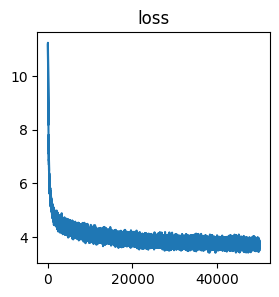

In [8]:
flow_matching.train(
    num_training_steps=50_000,
)
flow_matching.trainer.plot_training_logs()


### Sampling some events for each protocol condition.

In [9]:
out_dict = {}
n_samples_per_protocol = 10_000

for treatment in tqdm(flow_matching.train_data.seen_combinations):
    data = flow_matching.train_data.get_treatments(1, treatment)
    cond = {
        cov: torch.from_numpy(cov_data).repeat(n_samples_per_protocol, 1).float().to(flow_matching.device)
        for cov, cov_data in data.perturbation_data.items()
    }

    samples = flow_matching.predict(
        batch={
            "condition": cond
        },
    )
    out_dict[treatment] = samples.detach().cpu().numpy()


100%|██████████| 72/72 [00:28<00:00,  2.56it/s]


### Defining function to visualize generated samples.

In [10]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_pca", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    if plot_pcs:
        sc.pl.embedding(adata_generated, basis=key, color=coloring)
    if plot_umap:
        sc.pl.umap(adata_generated, color=coloring)
    return adata_generated


### Constructing Prediction anndata.

In [13]:
df_dict = {}

for col in EXPERIMENTAL_COLUMNS:
    if col not in df_dict.keys():
        df_dict[col] = []
    df_dict[col].extend(
        adata.obs[col].tolist()
    )

for treatment in flow_matching.train_data.seen_combinations:
    for cov_idx, cov_val in enumerate(treatment):
        col = EXPERIMENTAL_COLUMNS[cov_idx]
        if col not in df_dict.keys():
            df_dict[col] = []
        df_dict[col].extend(
            [
                cov_val for _ in range(n_samples_per_protocol)
            ]
        )


### Visualizing the generated samples.


In [ ]:
samples = np.concatenate(list(out_dict.values()), axis=0)
concatenate_adata_and_plot(
    adata,
    samples,
    key="X_repr",
    coloring=["dataset_type", ] + list(df_dict.keys()),
    **df_dict
)
